# Crux — Fine-tuning a YOLO26 Hold Detector (Transfer Learning)

**The graded core.** COCO — what `yolo26n.pt` is pretrained on — has **no `hold` class**.
So a COCO model scores ~0 mAP on climbing holds. We **fine-tune** it on a single-class
`hold` dataset (~417 images, 640×640) and measure the **before → after mAP gain**. That
gain *is* the transfer-learning result this notebook is graded on.

Where it fits: detect holds **once** on an empty-wall frame → a static hold map; a
pretrained pose model runs per frame; fusing them yields a climb **debrief** (contacts,
crux, feet cuts). This notebook owns the detector + its evaluation.

> Run top-to-bottom on **Colab (GPU)**. All logic lives in `training/train.py` and
> `training/eval.py` — the cells orchestrate and narrate, nothing is buried here.

## 1. Setup

> This notebook clones the **`jan/model`** branch directly (pinned in the cell below), so it
> already has the Model-role code (`train.py` / `eval.py` with `eval.run()` returning the
> before/after summary dict) — **no merge to `main` is needed yet**. Once `jan/model` is
> merged, change `-b jan/model` back to a plain clone.

In [1]:
import os, sys
# Colab: clone the jan/model branch once. Local: no-op (config.yaml already present).
if not os.path.exists("config.yaml") and not os.path.exists("Crux"):
    !git clone -q -b jan/model https://github.com/moanv2/Crux
if os.path.exists("Crux"):
    %cd Crux
!pip install -q -r requirements.txt

/content/Crux
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.4 MB/s eta 0:00:00


In [2]:
sys.path.insert(0, "data/scripts")
sys.path.insert(0, "training")
from config import load_config, resolve_paths
import train
import eval as evaluate          # Model-role modules — all logic lives here, not in cells
cfg = load_config()
paths = resolve_paths(cfg)
print("image_size:", cfg["image_size"], "| classes:", cfg["classes"])

image_size: 640 | classes: ['hold']


## 2. Get the dataset (Diego's pipeline)

Pulls Roboflow v3 → cleans → splits → writes `data/data.yaml` (single class `hold`).

In [3]:
import os
# Roboflow key — prefer a Colab secret named exactly ROBOFLOW_API_KEY (key icon -> Notebook
# access ON). Outside Colab, set os.environ["ROBOFLOW_API_KEY"]="<key>" before this cell.
try:
    from google.colab import userdata
    os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")
except Exception as e:
    print("No Colab secret loaded (", type(e).__name__, ") — using a manually set env var.")
assert os.environ.get("ROBOFLOW_API_KEY"), "Add a Colab secret named ROBOFLOW_API_KEY (Notebook access ON), or set os.environ['ROBOFLOW_API_KEY'] before this cell."
!python data/scripts/run_pipeline.py
from pathlib import Path
print("data.yaml exists:", paths.data_yaml.exists())
print(Path("data/data_card.md").read_text())

2026-06-23 09:20:40,456 INFO __main__: === download ===
loading Roboflow workspace...
loading Roboflow project...

Extracting Dataset Version Zip to /content/Crux/data/raw in yolov11:: 100% 855/855 [00:00<00:00, 6742.27it/s]
2026-06-23 09:20:47,349 INFO download: Downloaded diego-alfaro-s-workspace/climbing-replica-test-bdtpi v3 (yolov11) -> /content/Crux/data/raw
2026-06-23 09:20:47,349 INFO download: Record this version id (3) in data_card.md.
2026-06-23 09:20:47,349 INFO __main__: === clean ===
2026-06-23 09:20:53,733 INFO clean: clean: kept 417 | dropped 0 corrupt, 0 empty, 8 dupes -> /content/Crux/data/interim
2026-06-23 09:20:53,734 INFO __main__: === ingest_custom ===
2026-06-23 09:20:53,735 INFO ingest_custom: Ingesting custom photos from /content/Crux/data/custom/incoming (classes=['hold'])
2026-06-23 09:20:53,735 WARNING __main__: ingest_custom is not implemented yet: TODO: implement custom photo merge.
2026-06-23 09:20:53,735 INFO __main__: === stats ===
2026-06-23 09:20:53,

## 3. Peek at the data

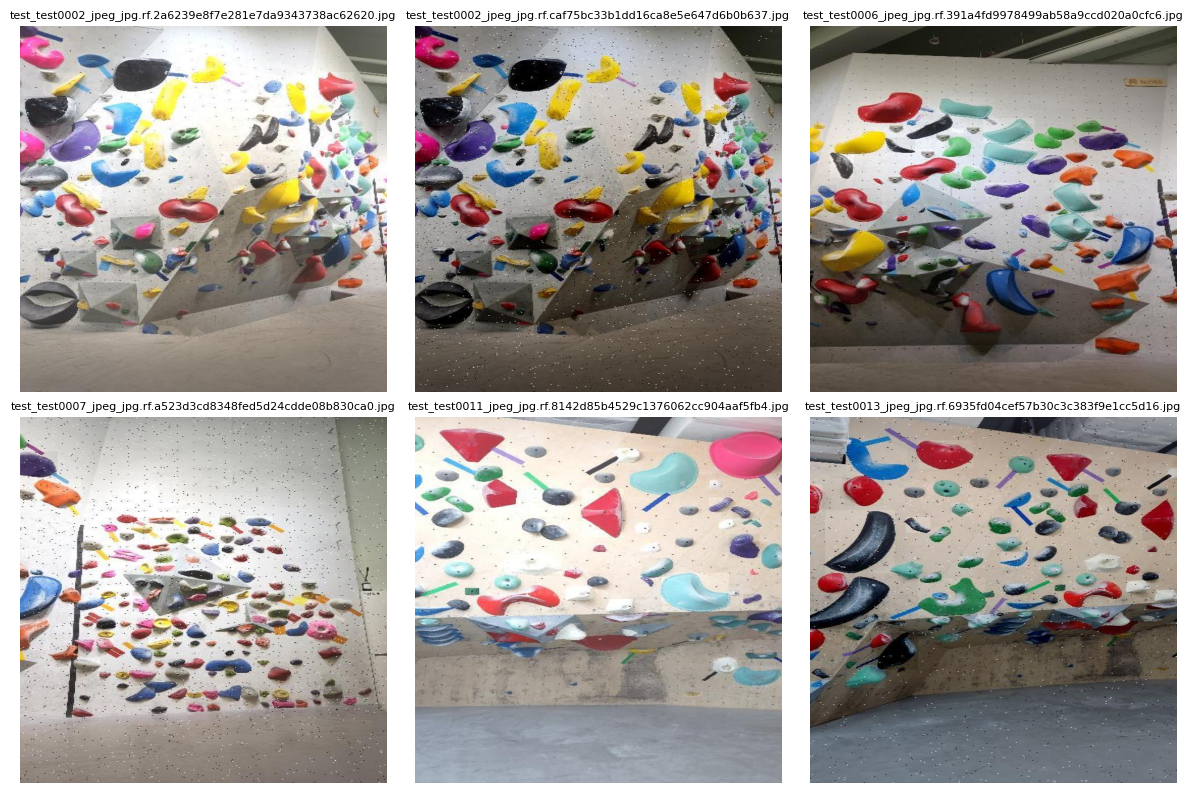

In [4]:
import yaml, matplotlib.pyplot as plt
from PIL import Image
d = yaml.safe_load(paths.data_yaml.read_text())
imgs = sorted((Path(d["path"]) / "train" / "images").glob("*"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, p in zip(axes.ravel(), imgs):
    ax.imshow(Image.open(p)); ax.set_title(p.name, fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Baseline (before): COCO-pretrained, zero-shot

Expect **~0 mAP** — COCO has no `hold` class, so the pretrained model cannot find holds. This is the *before* in the before/after.

In [5]:
from ultralytics import YOLO
base = YOLO(cfg["training"]["model"])    # COCO-pretrained — no `hold` class
split = evaluate.report_split(str(paths.data_yaml))   # held-out test split (fallback: val)
base_m = base.val(data=str(paths.data_yaml), imgsz=cfg["image_size"], split=split, name="nb_baseline")
print(f"Baseline ({split})  mAP50={base_m.box.map50:.4f}  mAP50-95={base_m.box.map:.4f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1645.5±491.9 MB/s, size: 55.9 KB)
val: Scanning /content/Crux/data/processed/test/labels... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 1.2Kit/s 0.0s
val: New cache created: /content/Crux/data/processed/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4s/it 4.3s
                   all         43       3474      0.302     0.0242    0.00773    0.00383
                pers

## 5. Fine-tune (transfer learning)

Reads every knob (epochs, batch, lr, augmentation) from `config.yaml`; copies the best checkpoint to `models/best.pt`. **Long GPU cell.**

In [6]:
weights = train.run(cfg, paths)   # -> models/best.pt
print("Frozen weights:", weights)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Crux/data/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, p

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 6. Evaluate (after) + handoff exports

Vals `best.pt` and the COCO baseline on the same data, writes `training/artifacts/metrics.{json,md}`, and copies the PR curve / confusion matrix / sample predictions there for Dalton.

In [8]:
summary = evaluate.run(cfg, paths)
from IPython.display import Markdown, display
display(Markdown((paths.root / "training" / "artifacts" / "metrics.md").read_text()))

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1495.6±923.7 MB/s, size: 80.7 KB)
val: Scanning /content/Crux/data/processed/test/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 15.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6s/it 4.7s
                   all         43       3474      0.836      0.779      0.823       0.49
Speed: 2.0ms preprocess, 46.7ms inference, 0.0ms loss, 10.4ms postprocess per image
Results saved to /content/Crux/runs/detect/eval_finetuned
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1083.1±392.1 MB/s, size: 67.7 KB)
va

_Metrics on the held-out **test** split._

| Model | mAP50 | mAP50-95 |
|---|---|---|
| COCO-pretrained (baseline) | 0.0077 | 0.0038 |
| Fine-tuned (best.pt) | 0.8234 | 0.4898 |
| **Δ (gain)** | **+0.8156** | **+0.4860** |


## 7. Before / after — the transfer-learning gain

The money shot: COCO baseline vs fine-tuned, side by side.

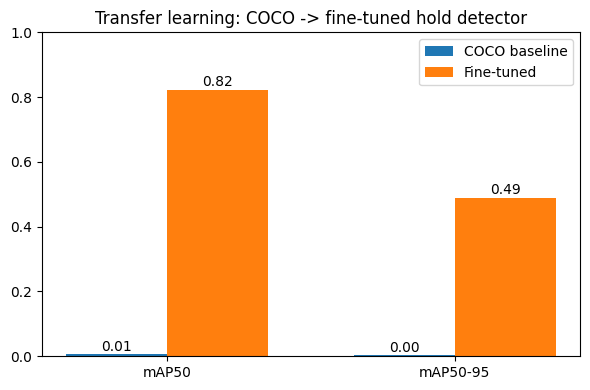

In [9]:
import matplotlib.pyplot as plt
labels = ["mAP50", "mAP50-95"]
base_v = [summary["baseline"]["map50"], summary["baseline"]["map"]]
fine_v = [summary["finetuned"]["map50"], summary["finetuned"]["map"]]
x = range(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([i - w/2 for i in x], base_v, w, label="COCO baseline")
ax.bar([i + w/2 for i in x], fine_v, w, label="Fine-tuned")
ax.set_xticks(list(x)); ax.set_xticklabels(labels); ax.set_ylim(0, 1)
ax.set_title("Transfer learning: COCO -> fine-tuned hold detector"); ax.legend()
for i, (b, f) in enumerate(zip(base_v, fine_v)):
    ax.text(i - w/2, b + 0.01, f"{b:.2f}", ha="center")
    ax.text(i + w/2, f + 0.01, f"{f:.2f}", ha="center")
plt.tight_layout()
plt.savefig(paths.root / "training" / "artifacts" / "before_after.png", dpi=150); plt.show()

## 8. Qualitative: PR curve + sample detections

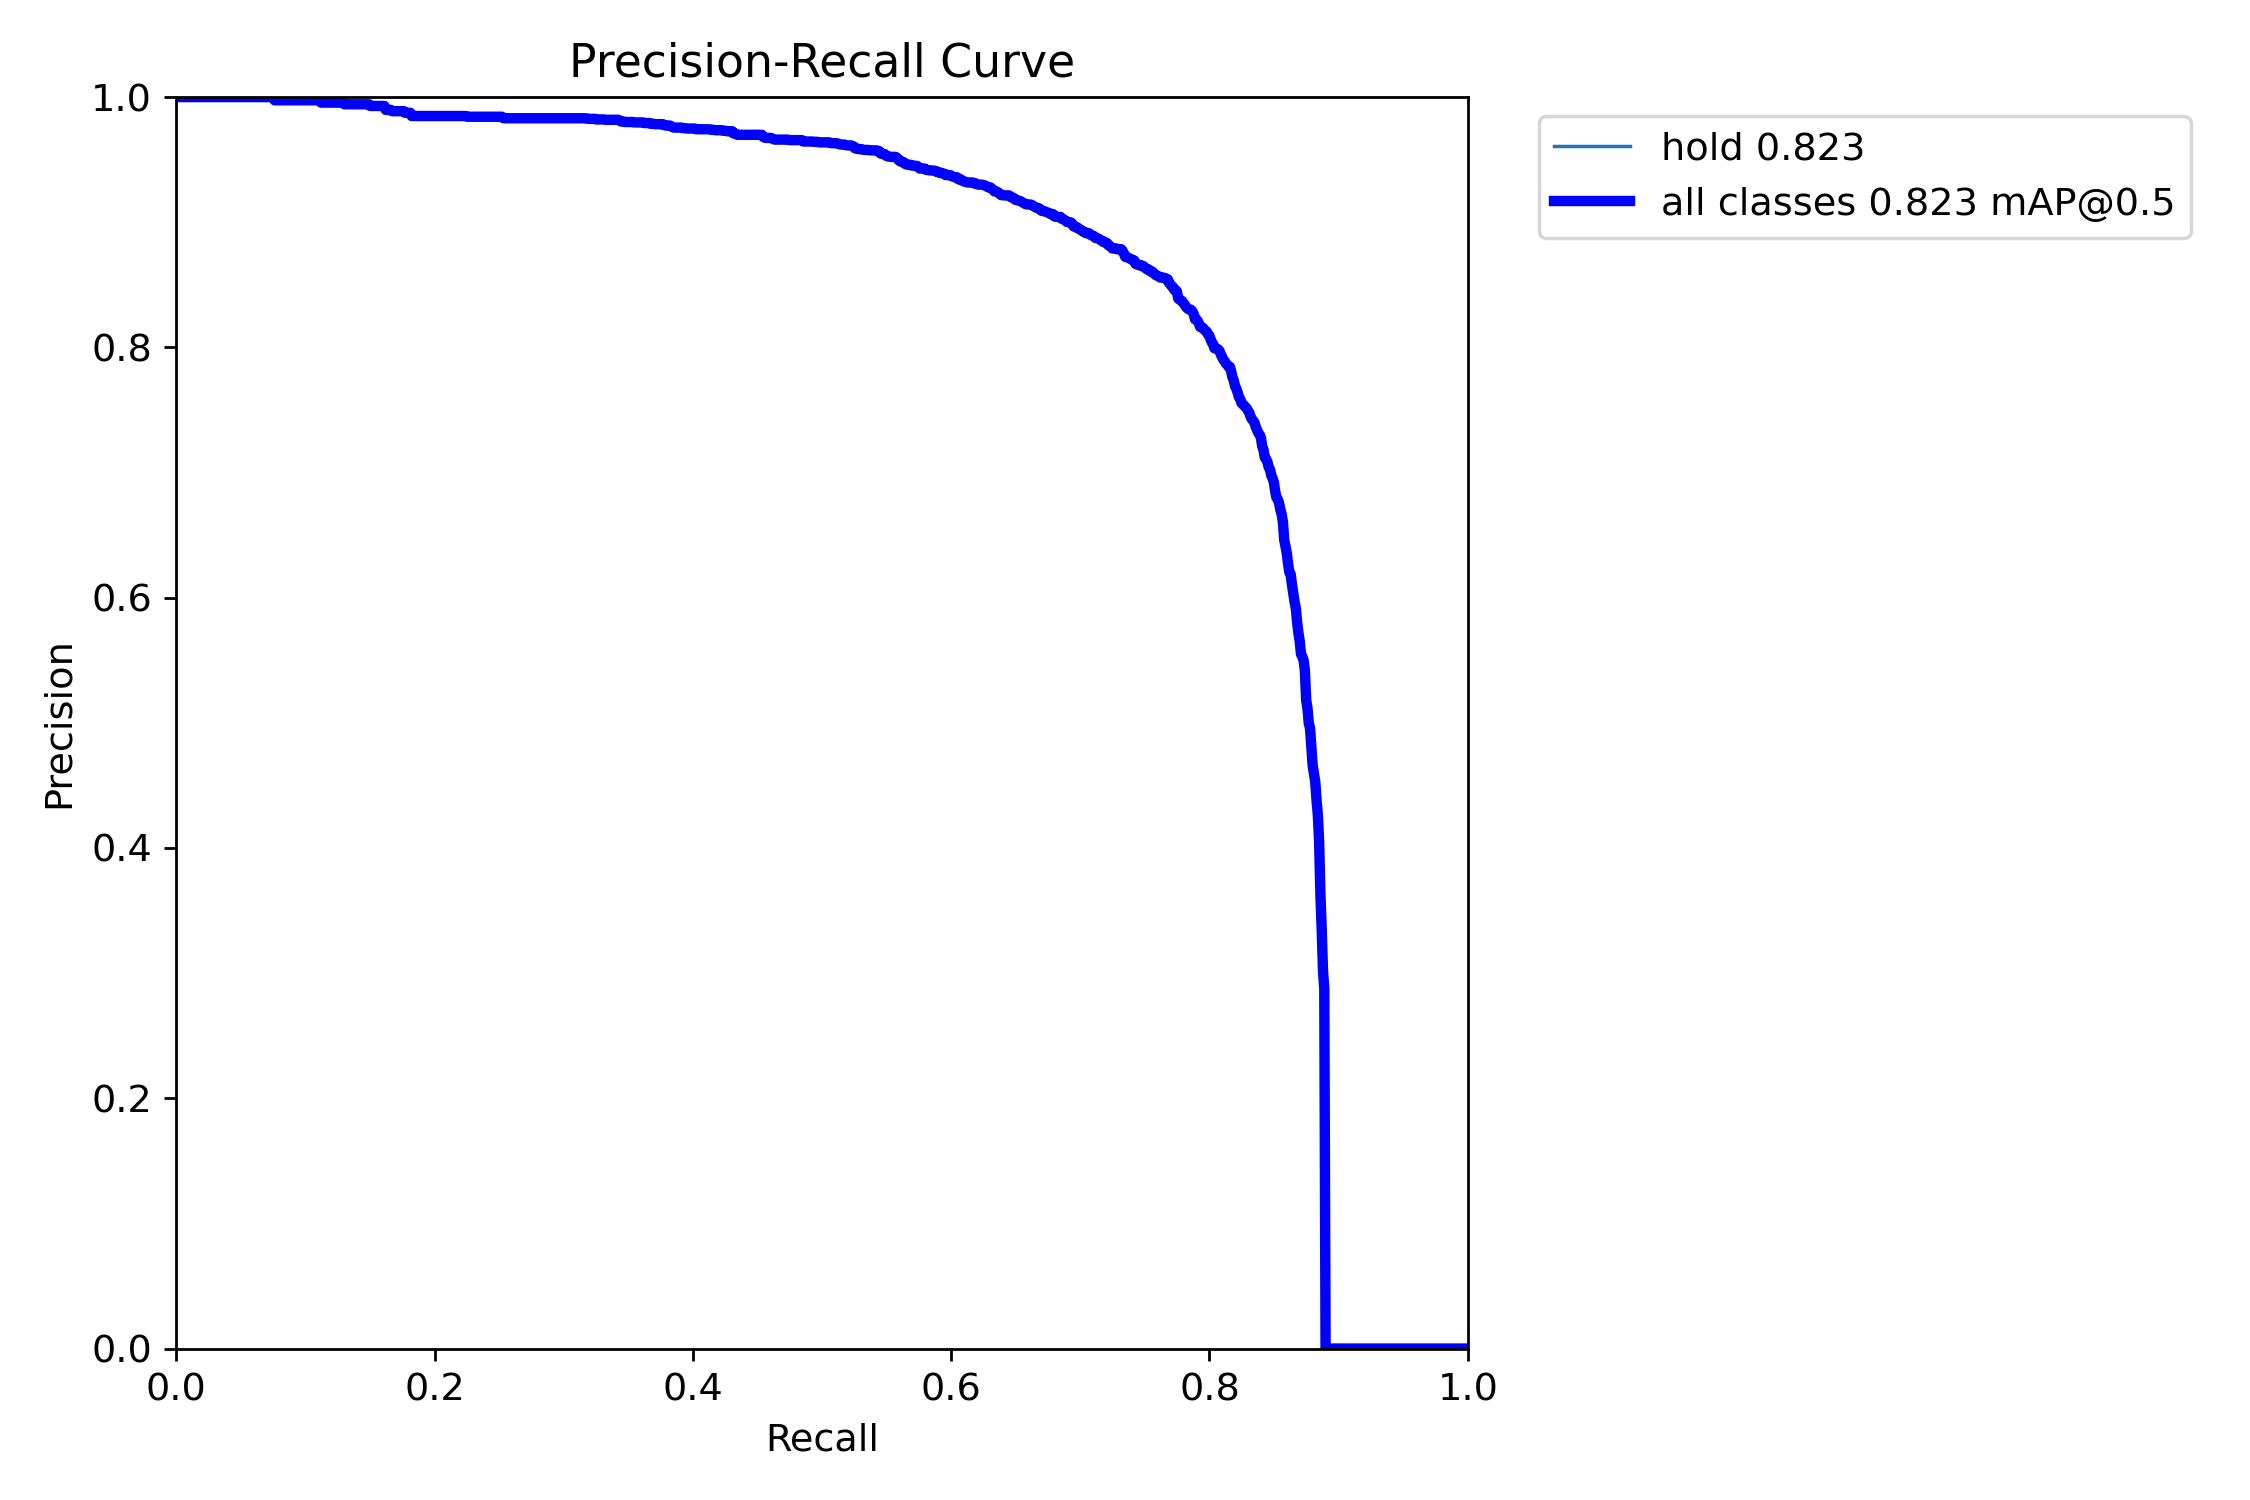

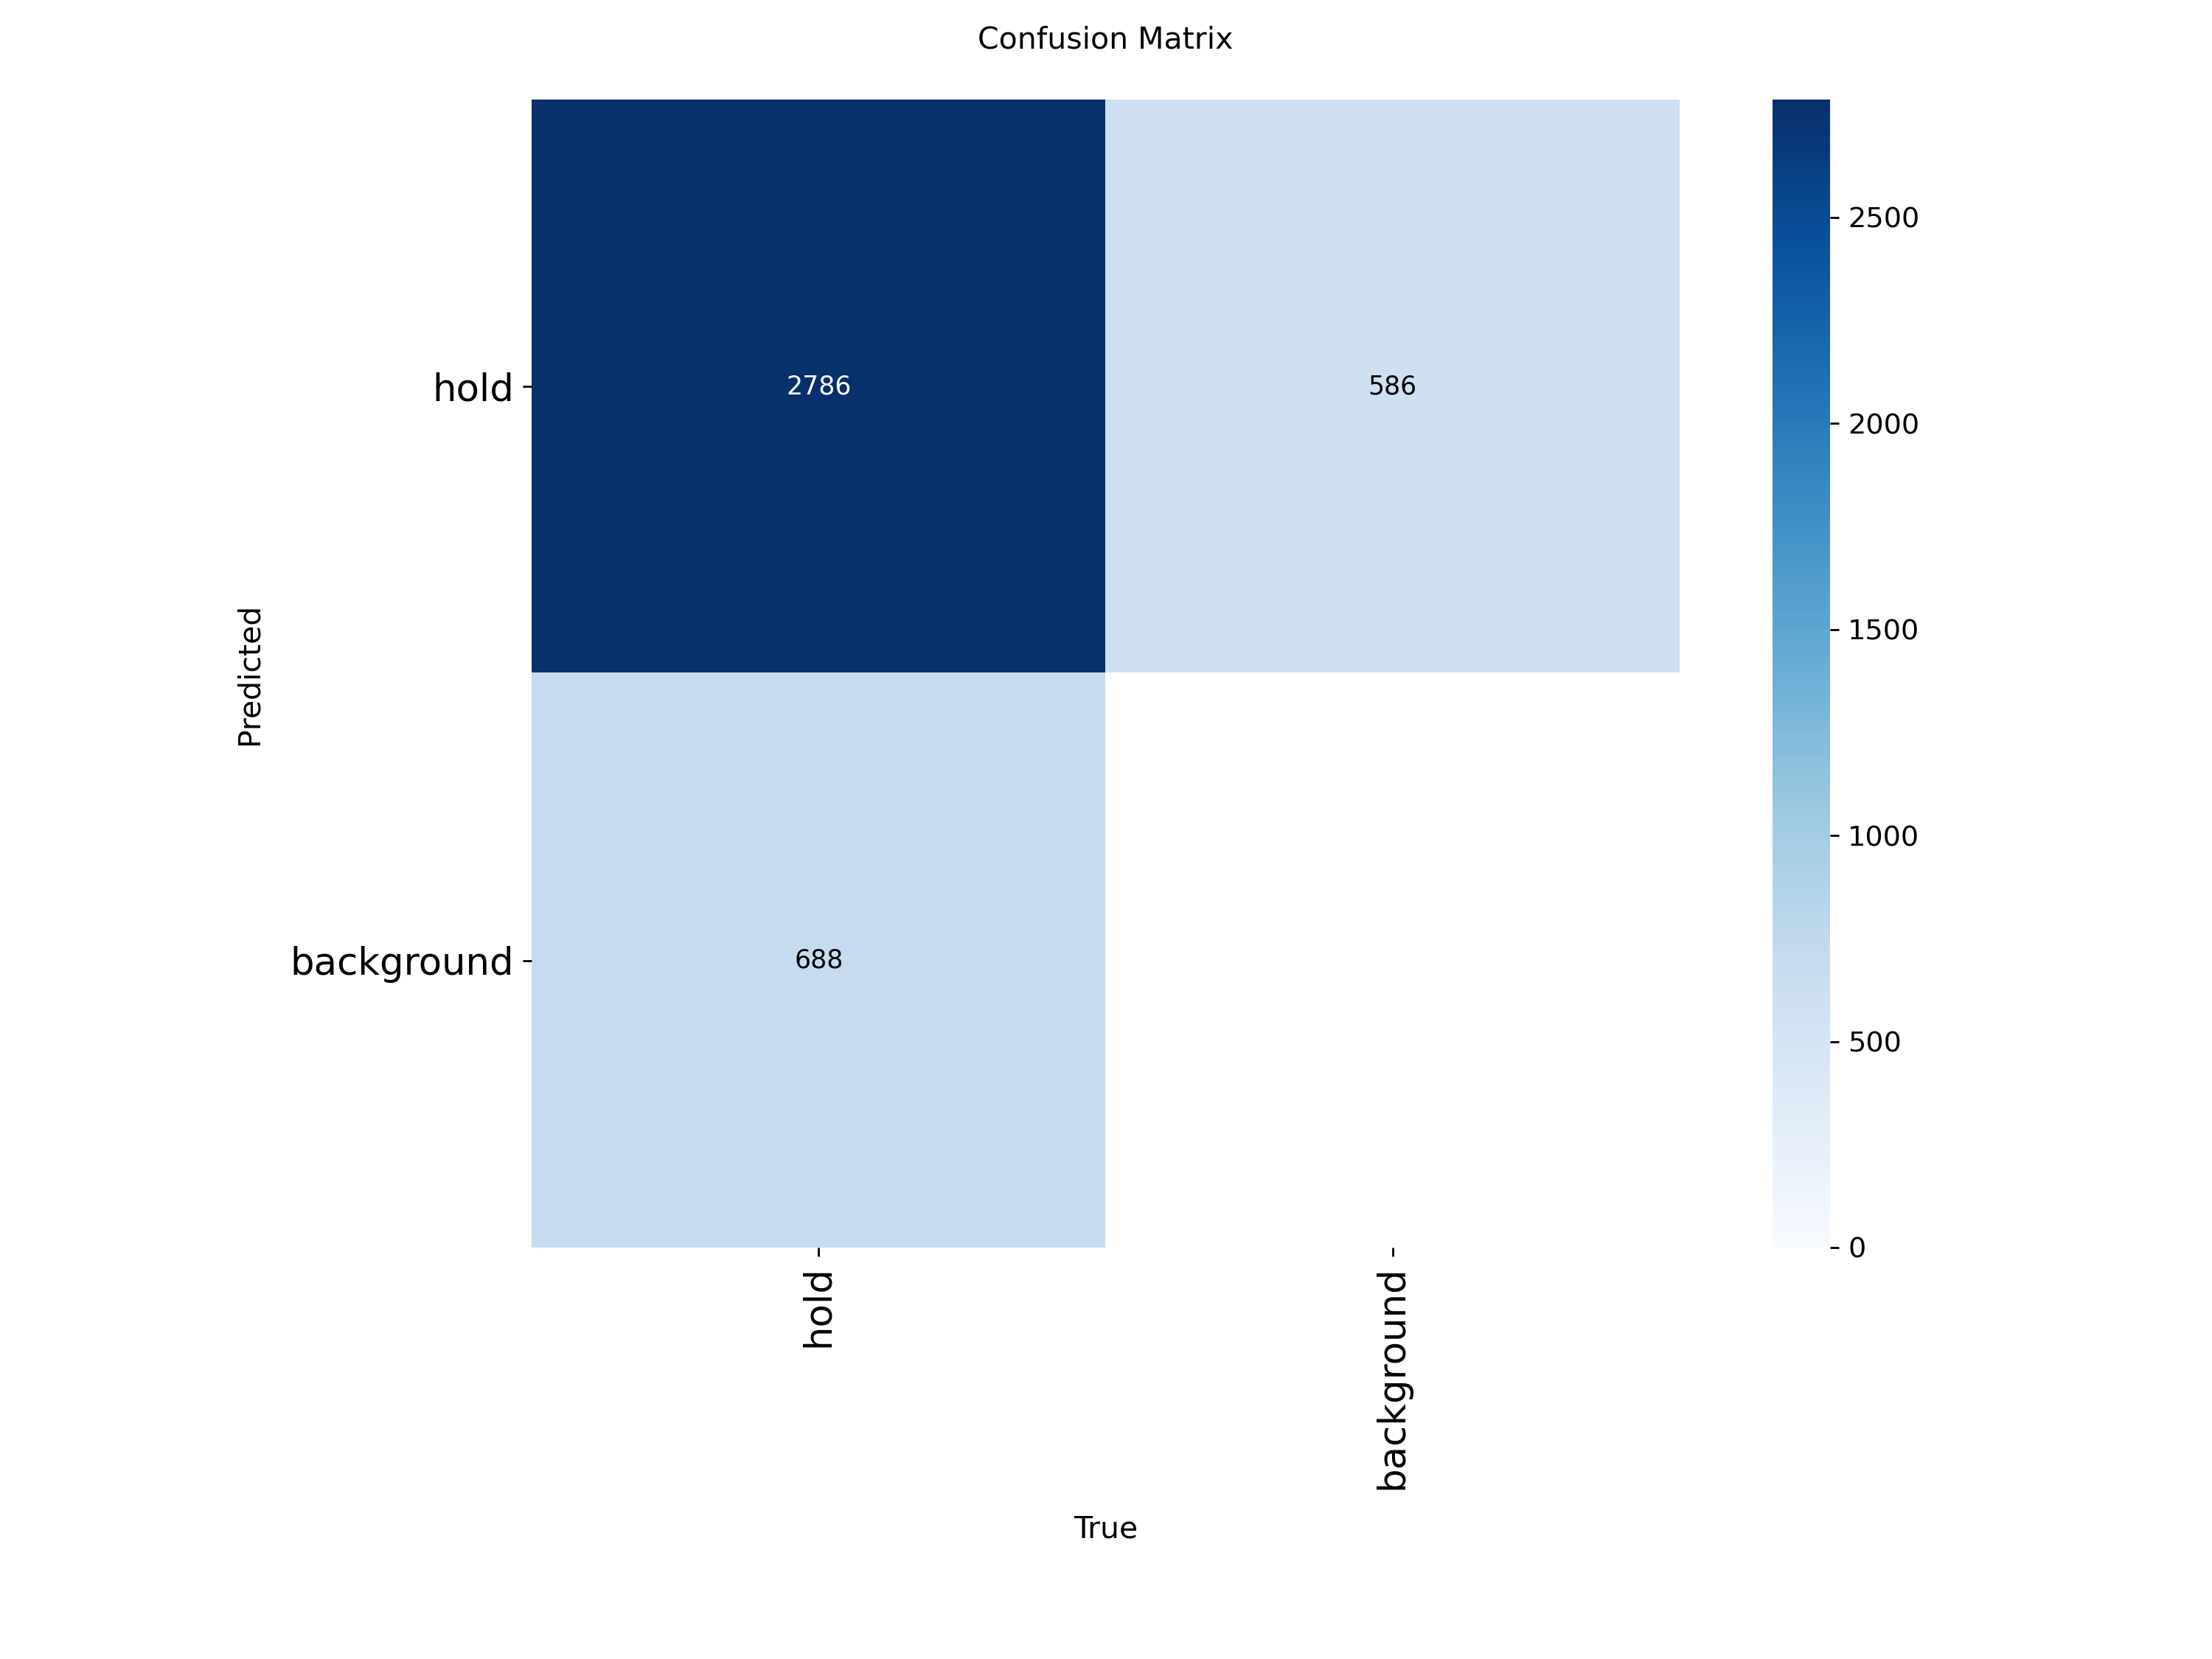

In [10]:
from IPython.display import Image as IPImage, display
art = paths.root / "training" / "artifacts"
for fig in ["BoxPR_curve.png", "PR_curve.png", "confusion_matrix.png"]:
    if (art / fig).exists():
        display(IPImage(str(art / fig)))

## 9. Inference demo — static hold map (-> Ignacio)

Run `best.pt` once on an empty-wall reference frame. This is exactly the hold map Ignacio's pipeline consumes.

In [11]:
split = evaluate.report_split(str(paths.data_yaml))
imgs = sorted(p for p in (Path(d["path"]) / split / "images").glob("*")
              if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
if not imgs:
    print("No reference image found — skipping inference demo.")
else:
    ref = imgs[0]
    det = YOLO(str(paths.weights)).predict(source=str(ref), imgsz=cfg["image_size"], save=True)
    print(f"Detected {len(det[0].boxes)} holds on {ref.name}")


image 1/1 /content/Crux/data/processed/test/images/test_test0006_jpeg_jpg.rf.bff2a4cdc59d43b7527df6751b2fa965.jpg: 640x640 112 holds, 11.6ms
Speed: 1.7ms preprocess, 11.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/Crux/runs/detect/predict
Detected 112 holds on test_test0006_jpeg_jpg.rf.bff2a4cdc59d43b7527df6751b2fa965.jpg


## 10. Handoff
- **`models/best.pt`** -> Ignacio (Integration): the one frozen detector.
- **`training/artifacts/`** (`metrics.json`, `metrics.md`, `before_after.png`, PR curve,
  confusion matrix, `samples/`) -> Dalton (Results/Docs) for the slides.

In [16]:
# === Export handoff artifacts to Google Drive (My Drive/IE/CVgroup) ===
import shutil
from pathlib import Path

DEST = Path("/content/drive/MyDrive/IE/CVgroup/model_handoff")   # <- edit if you want them loose in CVgroup

assert Path("/content/drive/MyDrive").exists(), \
    "Drive not mounted. Run: from google.colab import drive; drive.mount('/content/drive')"

REPO = Path("/content/Crux") if Path("/content/Crux").exists() else Path.cwd()
best = REPO / "models" / "best.pt"
artifacts = REPO / "training" / "artifacts"

assert best.exists(), f"{best} not found — run the fine-tune cell (train.run) first."

DEST.mkdir(parents=True, exist_ok=True)

# 1) Frozen detector -> Ignacio (Integration)
shutil.copy2(best, DEST / "best.pt")
print(f"[Ignacio]  best.pt   ({best.stat().st_size/1e6:.1f} MB)")

# 2) Metrics + figures -> Dalton (Results/Docs)
if artifacts.exists():
    shutil.copytree(artifacts, DEST / "artifacts", dirs_exist_ok=True)

    for p in sorted((DEST / "artifacts").rglob("*")):
        if p.is_file():
            print(
                f"[Dalton]   artifacts/{p.relative_to(DEST/'artifacts')} "
                f"({p.stat().st_size/1e3:.0f} KB)"
            )
else:
    print("WARNING: training/artifacts/ not found — run the eval cell first.")

print(f"\nDone -> {DEST}")

[Ignacio]  best.pt   (5.4 MB)
[Dalton]   artifacts/.gitkeep (0 KB)
[Dalton]   artifacts/BoxF1_curve.png (101 KB)
[Dalton]   artifacts/BoxPR_curve.png (89 KB)
[Dalton]   artifacts/before_after.png (30 KB)
[Dalton]   artifacts/confusion_matrix.png (99 KB)
[Dalton]   artifacts/confusion_matrix_normalized.png (95 KB)
[Dalton]   artifacts/metrics.json (0 KB)
[Dalton]   artifacts/metrics.md (0 KB)
[Dalton]   artifacts/results.png (288 KB)
[Dalton]   artifacts/samples/test_test0006_jpeg_jpg.rf.bff2a4cdc59d43b7527df6751b2fa965.jpg (228 KB)
[Dalton]   artifacts/samples/test_test0029_jpeg_jpg.rf.9beb96f3e419cfa64d17db888a19f752.jpg (318 KB)
[Dalton]   artifacts/samples/test_test0033_jpeg_jpg.rf.acae643d227899bb9a319f907edb2edc.jpg (273 KB)
[Dalton]   artifacts/samples/test_test0049_jpeg_jpg.rf.307a3ed0188984ede2c194e523d100ae.jpg (309 KB)
[Dalton]   artifacts/samples/test_test0051_jpeg_jpg.rf.41f2c835f879cf1288826909796c2bbd.jpg (294 KB)
[Dalton]   artifacts/samples/test_test0117_jpeg_jpg.rf.dfe